# PS-S6E01: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

**CatBoost** distinguishes itself with its native handling of categorical features, eliminating the need for extensive manual encoding (like One-Hot) often required by other gradient boosting libraries. It utilizes "Ordered Boosting" to combat target leakage and employs symmetric decision trees, which often leads to more robust generalization and faster inference speeds. This model is particularly effective when dealing with datasets containing a mix of numerical physiological markers and categorical demographic data without requiring complex preprocessing.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFECV
from catboost import CatBoostRegressor, Pool, EShapCalcType, EFeaturesSelectionAlgorithm

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering

In [5]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'binning',
    'interactions',
    'clustering',
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 29
   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc        7.910            98.800              no   
1   18   other  diploma        4.950            94.800             yes   
2   20  female     b.sc        4.680            92.600             yes   
3   19    male     b.sc        2.000            49.500             yes   
4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy 

In [7]:
def get_cat_features(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
        if c in df.columns:
            cat_cols.append(c)
    return list(dict.fromkeys(cat_cols))

cat_cols = get_cat_features(X)
print(f'Detected Categoricals: {cat_cols}')

print('Sanitizing categorical features...')

# Only cast true string categoricals; leave integer categoricals as ints
str_cats = [c for c in cat_cols if X[c].dtype == 'object' or str(X[c].dtype).startswith('category')]
if str_cats:
    X[str_cats] = X[str_cats].astype(str)
    X_test[str_cats] = X_test[str_cats].astype(str)

Detected Categoricals: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']
Sanitizing categorical features...


## Recursive Feature Elimination and Optuna Training

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [8]:
n_jobs = 1 if USE_GPU else -1

if PERFORM_RFE:    
    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    
    # Define the model
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        loss_function='RMSE',
        eval_metric='RMSE',
        cat_features=cat_features,
        verbose=200,
        random_state=seed,
        early_stopping_rounds=50
    )
    
    # CREATE A SPLIT FOR FEATURE SELECTION
    # We need a validation set so CatBoost knows which features generalize well
    X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Create CatBoost Pools (required for feature selection)
    train_pool = Pool(X_fs_train, y_fs_train, cat_features=cat_features)
    val_pool = Pool(X_fs_val, y_fs_val, cat_features=cat_features)   
    
    # Run Native Feature Selection
    summary = model.select_features(
        train_pool,
        eval_set=val_pool,
        features_for_select=train_pool.get_feature_names(), # Pass the list of column names
        num_features_to_select=20,                          # How many features you want to keep
        steps=1,                                            # How many elimination rounds
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,                            # We just want the list, we'll retrain later
        plot=False
    )
    
    # View Selected Features
    # Save the selected features for the next step
    optimal_cols = summary['selected_features_names']
    print('Selected Features:', optimal_cols)
else:
    print('Using all columns as optimal features.')
    optimal_cols = X.columns
                            
print('\nOptimal Features:')
print(optimal_cols)

Using all columns as optimal features.

Optimal Features:
Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'sleep_quality_ord',
       'facility_rating_ord', 'exam_difficulty_ord', 'class_attendance_class',
       'sleep_hours_class', 'study_hours_class', 'study_to_sleep_ratio',
       'attendance_to_study_ratio', 'total_engagement', 'autodidact_ratio',
       'weighted_study_hours', 'restoration_index', 'effort_coaching_hours',
       'effort_group_study_hours', 'effort_mixed_hours',
       'effort_online_videos_hours', 'effort_self_study_hours',
       'cluster_label'],
      dtype='object')


In [9]:
# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]

# Determine the cat_features for the new dataset
cat_features = get_cat_features(X_rfe)

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

print(f"Training shape: {X_rfe.shape}")
print(f"Categorical Features: {cat_features}")    
print(f"cols_to_keep: {cols_to_keep}")

def objective(trial):
    # Explicit garbage collection at start of trial
    gc.collect()

    # Define the Hyperparameter Search Space
    params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'iterations': 20000,                         # High cap, rely on early_stopping
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 100.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-4, 20.0, log=True),
        'border_count': trial.suggest_int('border_count', 64, 255),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),

        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise']),
        
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli']),
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'allow_writing_files': False,        # Stop it from spamming drive with log folders
        'random_seed': seed,
        'verbose': False,
    }
    
    if params['bootstrap_type'] == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    else:
        params['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)

    if params['task_type'] == 'CPU':
        params['rsm'] = trial.suggest_float('rsm', 0.5, 1.0)

    # Setup Cross-Validation Strategy
    # 5-Fold is standard. Shuffle is critical for regression to avoid sorting bias.
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    cv_scores = []
    
    # CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):
        X_train_fold, X_val_fold = X_rfe.iloc[train_idx], X_rfe.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Start with object/category
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Add discrete engineered columns explicitly
        for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
            if c in X_train_trans.columns:
                cat_cols.append(c)
        
        # De-dup while keeping order
        cat_cols = list(dict.fromkeys(cat_cols))
        
        # Only cast true string categoricals; leave integer categoricals as ints
        str_cats = [c for c in cat_cols if X_train_trans[c].dtype == 'object' or str(X_train_trans[c].dtype).startswith('category')]
        if str_cats:
            X_train_trans[str_cats] = X_train_trans[str_cats].astype(str)
            X_val_trans[str_cats]   = X_val_trans[str_cats].astype(str)
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols)
        val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)
        
        # Initialize and Fit
        model = CatBoostRegressor(**params)

        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        
        # Predict and Score
        preds = model.predict(val_pool)
        
        # Clip predictions to valid range (0-100) to improve RMSE
        preds = np.clip(preds, 0, 100)
        
        rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
        cv_scores.append(rmse)

    # Return the average RMSE across all folds
    return np.mean(cv_scores)

Training shape: (630000, 29)
Categorical Features: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']
cols_to_keep: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'sleep_quality_ord', 'facility_rating_ord', 'exam_difficulty_ord', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'study_to_sleep_ratio', 'attendance_to_study_ratio', 'total_engagement', 'autodidact_ratio', 'weighted_study_hours', 'restoration_index', 'effort_coaching_hours', 'effort_group_study_hours', 'effort_mixed_hours', 'effort_online_videos_hours', 'effort_self_study_hours', 'cluster_label']


In [10]:
if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    print("Starting Optuna Optimization...")

    # Use MedianPruner to stop trials that are performing worse than the median of previous trials
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    
    study = optuna.create_study(
        study_name='cb_student_test_scores_optuna', 
        direction='minimize',
        pruner=pruner
    )
    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.06731729017161406,
        'depth': 4,
        'l2_leaf_reg': 10.388205995392239,
        'random_strength': 0.014803125987274962,
        'border_count': 244,
        'one_hot_max_size': 16,
        'min_data_in_leaf': 94,
        'leaf_estimation_iterations': 3,
        'grow_policy': 'SymmetricTree',
        'bootstrap_type': 'Bernoulli',
        'subsample': 0.7498855477373203
    }

[I 2026-01-12 14:38:25,871] A new study created in memory with name: cb_student_test_scores_optuna


Starting Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-12 14:42:32,030] Trial 0 finished with value: 8.755952260610638 and parameters: {'learning_rate': 0.061394172407013295, 'depth': 4, 'l2_leaf_reg': 4.4998499196282795, 'random_strength': 0.10528097557860562, 'border_count': 177, 'one_hot_max_size': 16, 'min_data_in_leaf': 21, 'leaf_estimation_iterations': 6, 'grow_policy': 'SymmetricTree', 'bootstrap_type': 'Bernoulli', 'subsample': 0.6717333853247349}. Best is trial 0 with value: 8.755952260610638.
[I 2026-01-12 14:43:35,185] Trial 1 finished with value: 8.879280941541014 and parameters: {'learning_rate': 0.17448291225484006, 'depth': 9, 'l2_leaf_reg': 2.647717493396278, 'random_strength': 18.988418087376523, 'border_count': 101, 'one_hot_max_size': 20, 'min_data_in_leaf': 38, 'leaf_estimation_iterations': 5, 'grow_policy': 'Depthwise', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 6.07305086912252}. Best is trial 0 with value: 8.755952260610638.
[I 2026-01-12 14:46:23,515] Trial 2 finished with value: 8.8253798489486

## Model Training

In [11]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'task_type': 'CPU',  # We must use CPU if we want both training and validation numbers
    'random_state': seed,
    'verbose': 200,
    'allow_writing_files': False,        # Stop it from spamming drive with log folders
    'early_stopping_rounds': 200,
}

print('Final CatBoost CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(cb_tuned_params)

# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Initialize Standard K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):

    print(f"Starting processing of fold {fold+1}")

    # Create Folds
    X_train_fold = X_rfe.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = X_rfe.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Feature Engineering (Per fold to prevent leakage)
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    # Start with object/category
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Add discrete engineered columns explicitly
    for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
        if c in X_train_trans.columns:
            cat_cols.append(c)
    
    # De-dup while keeping order
    cat_cols = list(dict.fromkeys(cat_cols))
    
    # Only cast true string categoricals; leave integer categoricals as ints
    str_cats = [c for c in cat_cols if X_train_trans[c].dtype == 'object' or str(X_train_trans[c].dtype).startswith('category')]
    if str_cats:
        X_train_trans[str_cats] = X_train_trans[str_cats].astype(str)
        X_val_trans[str_cats]   = X_val_trans[str_cats].astype(str)
        X_test_trans[str_cats]  = X_test_trans[str_cats].astype(str)

    # Create CatBoost Pools and immediately delete the pandas DataFrames to free RAM
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)
    test_pool = Pool(X_test_trans, cat_features=cat_cols)

    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = cb.CatBoostRegressor(**cb_tuned_params)
            
    # Train Model
    model.fit(
        train_pool,
        # CatBoost automatically tracks metrics on the training set (learn)
        # We pass validation set to track generalization
        eval_set=[train_pool, val_pool],
        verbose=100,
        early_stopping_rounds=200,
        use_best_model=True
    )
    
    # Store Results
    eval_results.append(model.get_evals_result())
    models.append(model)    

    # Predict on the validation set
    val_probs = model.predict(val_pool)

    # CLIP predictions to valid range (0-100)
    # This is critical for RMSE optimization in bounded domains
    val_probs = np.clip(val_probs, 0, 100)

    # Store OOF predictions
    oof_preds[val_idx] = val_probs
    
    # Score this fold
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_probs))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.5f} (best_iteration={model.get_best_iteration()})")
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict(test_pool)
    test_probs = np.clip(test_probs, 0, 100)
    test_preds += test_probs / n_folds

# Final Metric Calculation
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {overall_rmse:.5f}")

Final CatBoost CV Training with OOF / Test predictions
Parameters used for training:
{'learning_rate': 0.06731729017161406, 'depth': 4, 'l2_leaf_reg': 10.388205995392239, 'random_strength': 0.014803125987274962, 'border_count': 244, 'one_hot_max_size': 16, 'min_data_in_leaf': 94, 'leaf_estimation_iterations': 3, 'grow_policy': 'SymmetricTree', 'bootstrap_type': 'Bernoulli', 'subsample': 0.7498855477373203, 'iterations': 8000, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'task_type': 'CPU', 'random_state': 10301, 'verbose': 200, 'allow_writing_files': False, 'early_stopping_rounds': 200}
Starting processing of fold 1
0:	learn: 18.0965200	test: 18.0965200	test1: 18.1123558	best: 18.1123558 (0)	total: 78.6ms	remaining: 10m 28s
100:	learn: 8.9147101	test: 8.9147101	test1: 8.9201817	best: 8.9201817 (100)	total: 5.77s	remaining: 7m 31s
200:	learn: 8.8526348	test: 8.8526348	test1: 8.8639399	best: 8.8639399 (200)	total: 11.5s	remaining: 7m 25s
300:	learn: 8.8321371	test: 8.8321371	test1: 8.

## Visualizing Model Performance
We use four key plots to diagnose the health of our regression model

### Learning Curves (Train vs. Validation RMSE)
This plot tracks the Root Mean Squared Error (RMSE) for both the training set (Blue) and validation set (Red) over each boosting iteration.

* **What to look for:** You want the Validation (Red) curve to go down and flatten out.
* **Overfitting:** If the Blue line keeps dropping rapidly but the Red line starts rising, the model is memorizing the training data.
* **Underfitting:** If both lines are high and flat, the model isn't learning enough complexity.
* **Ideal:** The Red line reaches a minimum low value and stays there. The gap between Blue and Red should not be massive.

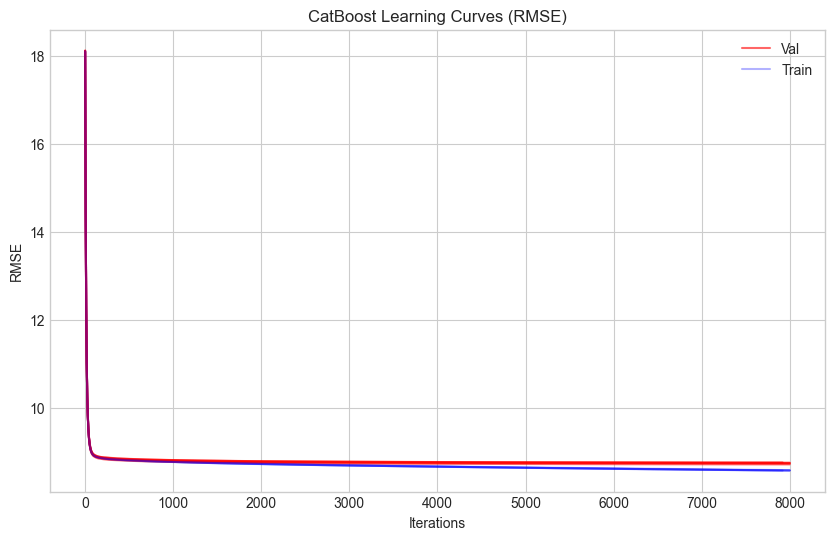

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='rmse')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features make sense (e.g., `study_hours` or `class_attendance` should likely be high).
* **Sanity Check:** If `id` or a random noise column appears in the top 5, there is a data leakage problem.
* **Engineering Check:** Look for the engineered features (e.g., `restoration_index`, `interaction_score`). If they appear near the top, the feature engineering added real value.

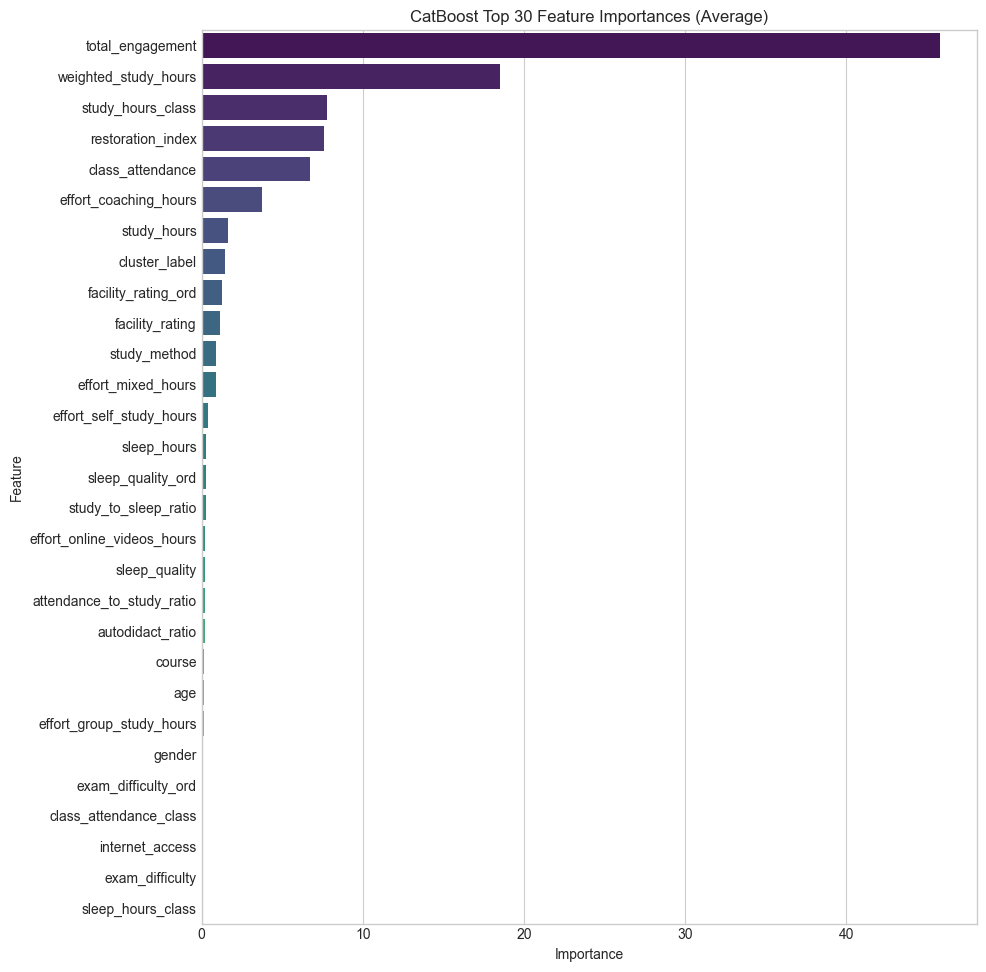

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

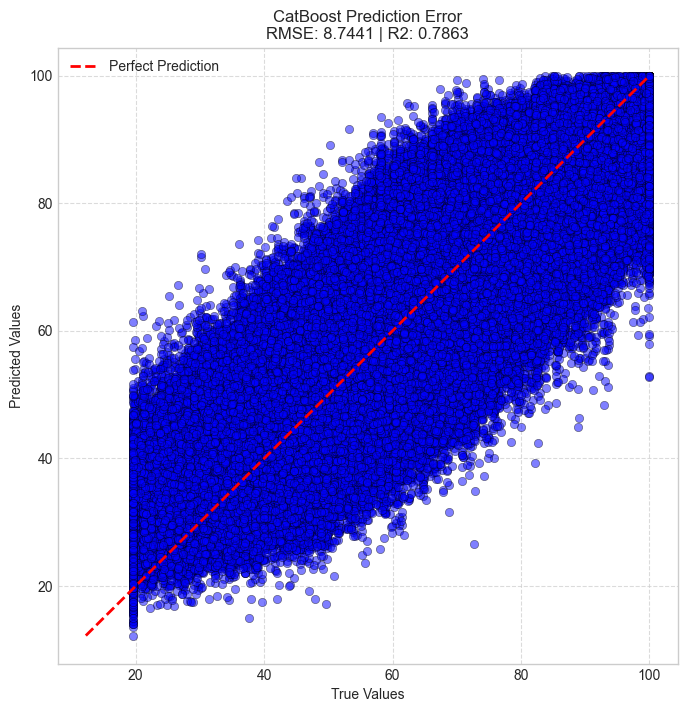

In [14]:
mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

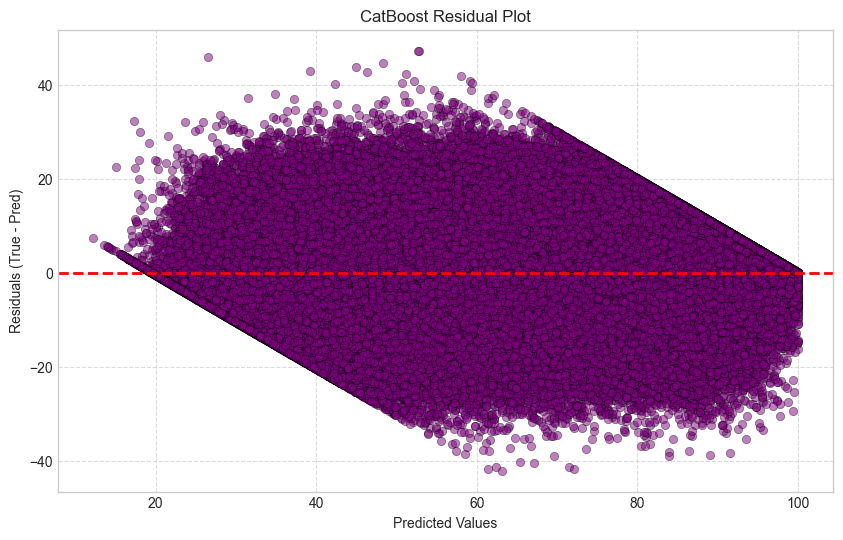

In [15]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [16]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.704
1  630001      70.089
2  630002      88.390
3  630003      55.720
4  630004      47.328
5  630005      71.300
6  630006      73.625
7  630007      58.170
8  630008      78.682
9  630009      90.427


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_cb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/cb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_cb': test_preds})
test_pred_df.to_csv(f'{output_dir}/cb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/cb_oof_preds.csv, {output_dir}/cb_test_preds.csv')

Saved for Blending: predictions/cb_oof_preds.csv, predictions/cb_test_preds.csv
